In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Crosstab Tutorial ---

In [2]:

## Creating a Sample Survey DataFrame
data = {
    'Nationality': ['USA', 'UK', 'India', 'USA', 'India', 'UK'],
    'Handedness': ['Right', 'Left', 'Right', 'Left', 'Right', 'Left'],
    'Sex': ['Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'Age': [25, 30, 35, 40, 45, 50]
}
df_survey = pd.DataFrame(data)
print("Survey DataFrame:")
print(df_survey)

Survey DataFrame:
  Nationality Handedness     Sex  Age
0         USA      Right    Male   25
1          UK       Left  Female   30
2       India      Right    Male   35
3         USA       Left  Female   40
4       India      Right    Male   45
5          UK       Left  Female   50


In [4]:
## Crosstab Examples
# like a pivot table?

print("\nCrosstab of Nationality and Handedness:")
print(pd.crosstab(df_survey.Nationality, df_survey.Handedness))

print("\nCrosstab of Sex and Handedness:")
print(pd.crosstab(df_survey.Sex, df_survey.Handedness))


Crosstab of Nationality and Handedness:
Handedness   Left  Right
Nationality             
India           0      2
UK              2      0
USA             1      1

Crosstab of Sex and Handedness:
Handedness  Left  Right
Sex                    
Female         3      0
Male           0      3


In [5]:
# Margins (Totals)
print("\nCrosstab with Margins:")
print(pd.crosstab(df_survey.Sex, df_survey.Handedness, margins=True))


Crosstab with Margins:
Handedness  Left  Right  All
Sex                         
Female         3      0    3
Male           0      3    3
All            3      3    6


In [7]:
## Multi-Index Columns and Rows
print("\nMulti-Index Crosstab:")
print(pd.crosstab(df_survey.Sex, [df_survey.Handedness, df_survey.Nationality], margins=True))


Multi-Index Crosstab:
Handedness  Left     Right     All
Nationality   UK USA India USA    
Sex                               
Female         2   1     0   0   3
Male           0   0     2   1   3
All            2   1     2   1   6


In [8]:
print(pd.crosstab([df_survey.Nationality, df_survey.Sex], df_survey.Handedness, margins=True))

Handedness          Left  Right  All
Nationality Sex                     
India       Male       0      2    2
UK          Female     2      0    2
USA         Female     1      0    1
            Male       0      1    1
All                    3      3    6


In [13]:
## Aggregation Function
print("\nCrosstab with Aggregation:")
print(pd.crosstab(df_survey.Sex, df_survey.Nationality))


Crosstab with Aggregation:
Nationality  India  UK  USA
Sex                        
Female           0   2    1
Male             2   0    1


In [10]:
## Normalization
print("\nNormalized Crosstab:")
print(pd.crosstab(df_survey.Sex, df_survey.Nationality, normalize='index'))


Normalized Crosstab:
Nationality     India        UK       USA
Sex                                      
Female       0.000000  0.666667  0.333333
Male         0.666667  0.000000  0.333333


# --- Reshaping DataFrame using Melt ---

In [15]:
## Creating a Weather DataFrame
data_weather = {
    'Day': ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    'Chicago': [32, 30, 28, 22, 30, 20, 25],
    'Chennai': [75, 77, 75, 82, 83, 81, 77],
    'Berlin': [41, 43, 45, 38, 30, 45, 47]
}
df_weather = pd.DataFrame(data_weather)
print("\nWeather DataFrame:")
print(df_weather)


Weather DataFrame:
         Day  Chicago  Chennai  Berlin
0     Monday       32       75      41
1    Tuesday       30       77      43
2  Wednesday       28       75      45
3   Thursday       22       82      38
4     Friday       30       83      30
5   Saturday       20       81      45
6     Sunday       25       77      47


In [ ]:
## Melting DataFrame
melted = pd.melt(df_weather, id_vars=["Day"], var_name='City', value_name='Temperature')
print("\nMelted DataFrame:")
print(melted)



Melted DataFrame:
          Day     City  Temperature
0      Monday  Chicago           32
1     Tuesday  Chicago           30
2   Wednesday  Chicago           28
3    Thursday  Chicago           22
4      Friday  Chicago           30
5    Saturday  Chicago           20
6      Sunday  Chicago           25
7      Monday  Chennai           75
8     Tuesday  Chennai           77
9   Wednesday  Chennai           75
10   Thursday  Chennai           82
11     Friday  Chennai           83
12   Saturday  Chennai           81
13     Sunday  Chennai           77
14     Monday   Berlin           41
15    Tuesday   Berlin           43
16  Wednesday   Berlin           45
17   Thursday   Berlin           38
18     Friday   Berlin           30
19   Saturday   Berlin           45
20     Sunday   Berlin           47



# --- Reshaping DataFrame using Stack/Unstack ---

In [19]:

## Creating a Sample Stocks DataFrame
data_stocks = {
    ('Stock A', 'Open'): [100, 102],
    ('Stock A', 'Close'): [105, 107],
    ('Stock B', 'Open'): [200, 202],
    ('Stock B', 'Close'): [205, 207]
}
df_stocks = pd.DataFrame(data_stocks, index=['Day 1', 'Day 2'])
print("\nStocks DataFrame:")
print(df_stocks)


Stocks DataFrame:
      Stock A       Stock B      
         Open Close    Open Close
Day 1     100   105     200   205
Day 2     102   107     202   207


In [ ]:
## Stacking DataFrame
stacked_df = df_stocks.stack()
print("\nStacked DataFrame:")
print(stacked_df)



Stacked DataFrame:
             Stock A  Stock B
Day 1 Close      105      205
      Open       100      200
Day 2 Close      107      207
      Open       102      202


C:\Users\RhysL\AppData\Local\Temp\ipykernel_2452\2125496677.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked_df = df_stocks.stack()


In [ ]:
## Unstacking DataFrame
unstacked_df = stacked_df.unstack()
print("\nUnstacked DataFrame:")
print(unstacked_df)



Unstacked DataFrame:
      Stock A      Stock B     
        Close Open   Close Open
Day 1     105  100     205  200
Day 2     107  102     207  202


In [22]:
## Stacking at Specific Levels
print("\nStacked at Level 0:")
print(df_stocks.stack(level=0))



Stacked at Level 0:
               Open  Close
Day 1 Stock A   100    105
      Stock B   200    205
Day 2 Stock A   102    107
      Stock B   202    207


C:\Users\RhysL\AppData\Local\Temp\ipykernel_2452\1255880720.py:3: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  print(df_stocks.stack(level=0))


In [23]:
# --- Multi-Level Column Headers ---
## Creating a Multi-Level Stocks DataFrame
data_stocks_3_levels = {
    ('Company A', 'Stock A', 'Open'): [100, 102],
    ('Company A', 'Stock A', 'Close'): [105, 107],
    ('Company B', 'Stock B', 'Open'): [200, 202],
    ('Company B', 'Stock B', 'Close'): [205, 207]
}
df_stocks_3 = pd.DataFrame(data_stocks_3_levels, index=['Day 1', 'Day 2'])
print("\nMulti-Level Stocks DataFrame:")
print(df_stocks_3)



Multi-Level Stocks DataFrame:
      Company A       Company B      
        Stock A         Stock B      
           Open Close      Open Close
Day 1       100   105       200   205
Day 2       102   107       202   207


In [ ]:
## Stacking Multi-Level Columns
print("\nStacked Multi-Level DataFrame:")
print(df_stocks_3.stack())



Stacked Multi-Level DataFrame:
            Company A Company B
              Stock A   Stock B
Day 1 Close       105       205
      Open        100       200
Day 2 Close       107       207
      Open        102       202


C:\Users\RhysL\AppData\Local\Temp\ipykernel_2452\1525933658.py:3: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  print(df_stocks_3.stack())


In [25]:
print("\nStacked at Level 1:")
print(df_stocks_3.stack(level=1))



Stacked at Level 1:
              Company A        Company B       
                   Open  Close      Open  Close
Day 1 Stock A     100.0  105.0       NaN    NaN
      Stock B       NaN    NaN     200.0  205.0
Day 2 Stock A     102.0  107.0       NaN    NaN
      Stock B       NaN    NaN     202.0  207.0


C:\Users\RhysL\AppData\Local\Temp\ipykernel_2452\128566145.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  print(df_stocks_3.stack(level=1))


In [27]:
# --- Visualization ---
## Creating a Sales DataFrame
data_sales = {
    'Year': [2022, 2023, 2024],
    'Sales_A': [100, 120, 140],
    'Sales_B': [80, 90, 100]
}
df_sales = pd.DataFrame(data_sales)
print(df_sales)

   Year  Sales_A  Sales_B
0  2022      100       80
1  2023      120       90
2  2024      140      100


In [28]:
## Stacking for Visualization
stacked_sales = df_sales.set_index('Year').stack().reset_index()
stacked_sales.columns = ['Year', 'Product', 'Sales']
print(stacked_sales)


   Year  Product  Sales
0  2022  Sales_A    100
1  2022  Sales_B     80
2  2023  Sales_A    120
3  2023  Sales_B     90
4  2024  Sales_A    140
5  2024  Sales_B    100


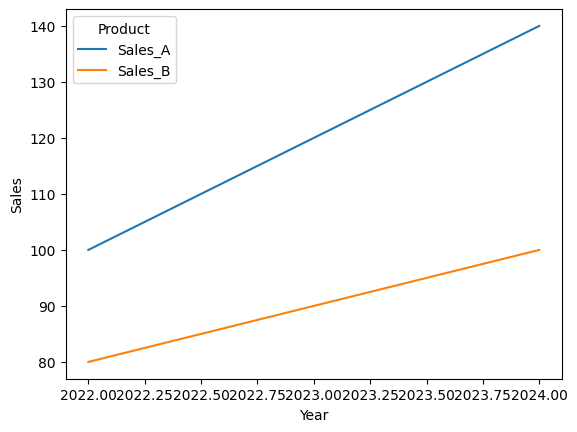

In [29]:
## Plotting Sales Data
sns.lineplot(data=stacked_sales, x='Year', y='Sales', hue='Product')
plt.show()
